In [1]:
# A décommenter à la première exécution si jupyter se plaint de ne pas trouver oracledb
!pip install --upgrade oracledb

In [2]:
# Compléter ici les imports dont vous avez besoin, ne pas modifier ceux déjà présents
import getpass
from os import getenv
import pandas as pd
import oracledb
import warnings
import matplotlib.pyplot as plt

In [3]:
# Nécessaire pour éviter les problèmes de session
class Connexion(object):
    def __init__(self, login, password):
        self.conn = oracledb.connect(
            user=login,
            password=password,
            host="oracle.iut-orsay.fr",
            port=1521,
            sid="etudom",
        )
        self.conn.autocommit = False

    def __enter__(self):
        self.conn.autocommit = False
        return self.conn

    def __exit__(self, *args):
        self.conn.close()

In [4]:
# La fonction ci-dessous est à utiliser pour exécuter une requête et stocker les résultats dans un dataframe Pandas sans afficher d’alerte.
# Vous pouvez vous en inspirer pour créer vos propres fonctions.
def requete_vers_dataframe(connexion_data, requete, valeurs = None):
    with Connexion(login=connexion_data['login'], password=connexion_data['password']) as connexion:
        warnings.simplefilter(action='ignore', category=UserWarning)
        if valeurs is not None:
            df = pd.read_sql(requete, connexion, params=valeurs)
        else:
            df = pd.read_sql(requete, connexion)
        warnings.simplefilter("always") 
        return df

In [26]:
# Saisir ci-dessous la plateforme qui vous a été attribuée. Cela correspond au nomPlateforme dans la table PLATEFORME de la base de données
# Par exemple NOM_PLATEFORME = "Switch"
NOM_PLATEFORME = "Nintendo Entertainment System"
# Saisir ci-dessous le login court de la base utilisée pour votre carnet
SCHEMA = '"PSOUNOU"'

# TABLEAU DE BORD PLATEFORME

## Partie consultation des données

In [32]:
# On demande à l'utilisateur son login et mot de passe pour pouvoir accéder à la base de données
if getenv("DB_LOGIN") is None:
    login = input("Login : ")
else:
    login = getenv("DB_LOGIN")
if getenv("DB_PASS") is None:
    password = getpass.getpass("Mot de passe : ")
else:
    password = getenv("DB_PASS")
conn = {'login': login, 'password': password}

Login :  psounou
Mot de passe :  ········


In [33]:
# On vérifie que l'utilisateur est bien connecté à la base de données, que le schéma est bon, et qu'on trouve la bonne plateforme
data = requete_vers_dataframe(conn, f"SELECT * FROM {SCHEMA}.PLATEFORME WHERE nomPlateforme LIKE (:libelle)",{"libelle":NOM_PLATEFORME})
id_plateforme = int(data.IDPLATEFORME.iloc[0])
print(f"Identifiant de la plateforme : {id_plateforme}")

Identifiant de la plateforme : 18


# Présentation générale de la plateforme qui vous a été assignée

La Nintendo Entertainment System, par abréviation NES. distribuée à partir de 1985 (1987 en Europe)
La NES voit le jour au Japon en 1981. Elle possède la plus grande longévité parmi toutes les consoles (devant l'Atari 2600 et la PlayStation). En tout, 1 251 jeux ont été créés pour cette console, sans distinction de région.

La console a connu un triomphe à l'échelle mondiale, contribuant à revitaliser l'industrie du jeu vidéo suite au crash de 1983. Elle a également établi des références pour les consoles futures, en matière de conception de jeux et de procédures de gestion. C'est la treizième console de jeux vidéo la plus populaire, avec 62 millions d'exemplaires écoulés.

### Début
Sa première génération de console est la NES ( Nintendo Entertainment System ) aux Etats Unis.  
Au Japon sous le nom de Famicom le 15 juillet 1983 .
En Europe, arrivée en 1986‑1987

### Fin
Cessation de la production de la NES en Amérique du Nord et en Europe le 14 août 1995 .
En mode console japonais (Famicom), la production s’est poursuivie jusqu’en septembre 2003, avec une assistance (réparations) assurée jusqu’en 2007 .
Appartient à la troisième génération de consoles (ère 8 bits). La Famicom/NES a renoué avec la popularité des jeux vidéos après le krach de 1983 .
Elle réalise des jeux tournée vers la famille avec des titres majeures comme: Mario, The Legend of Zelda, Kirby, Metroid.

### Ordre
Ce n’est pas la première : la Famicom est sortie avant la NES, en 1983. Donc la famille Famicom/NES inclut au minimum deux versions : Famicom (1983), NES originale (1985/86) et redesigns ultérieurs comme le NES‑101 en 1993 .

### Top-Sellers
Super Mario Bros. : 40 M ventes (titre le plus vendu sur NES)
Duck Hunt : 28 M.
Super Mario Bros. 3 : 18 M
The Legend of Zelda : 6,5 M
Super Mario Bros. 2 : 7,5 M

Source: 
https://fr.wikipedia.org/wiki/Nintendo_Entertainment_System
https://www.nintendo.com/fr-fr/Divers/Nintendo-Classic-Mini-Nintendo-Entertainment-System/Nintendo-Classic-Mini-Nintendo-Entertainment-System-1124287.html
https://youtu.be/04UYq_mlOI8?si=VDv9zBkusq--F-vm
https://www.igdb.com/top-100/games/platform/nes

## Graphique Pertinent

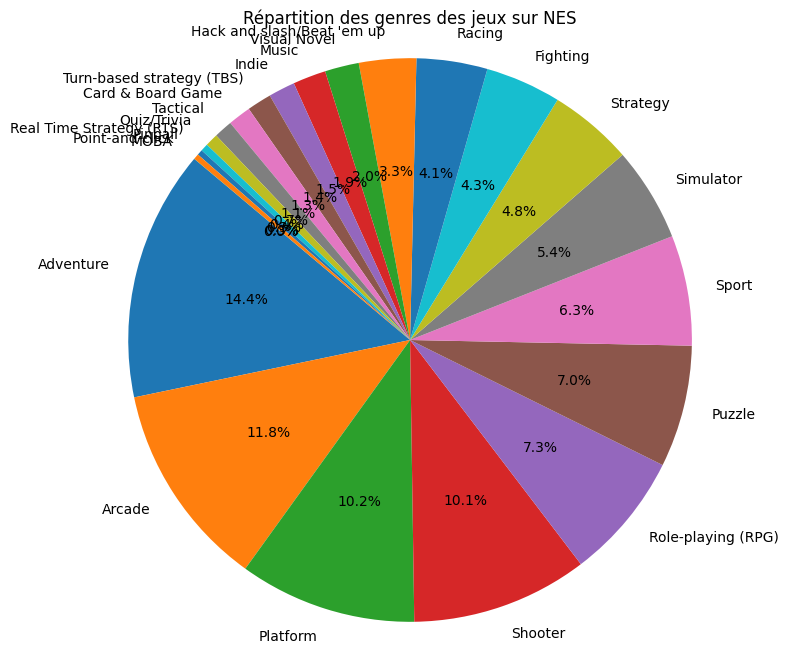

In [37]:
data_genre = requete_vers_dataframe(conn, """
    SELECT G.NOMGENRE, COUNT(*) AS NB_JEUX
    FROM {1}.COMPAGNIE C
    INNER JOIN COMPAGNIEJEU CJ ON C.IDCOMPAGNIE = CJ.IDCOMPAGNIE
    INNER JOIN {1}.JEU J ON CJ.IDJEU = J.IDJEU
    INNER JOIN {1}.DATESORTIE DS ON J.IDJEU = DS.IDJEU
    INNER JOIN {1}.GENREJEU GJ ON J.IDJEU = GJ.IDJEU
    INNER JOIN {1}.GENRE G ON GJ.IDGENRE = G.IDGENRE
    --WHERE C.NOMCOMPAGNIE = 'Nintendo'
    GROUP BY G.NOMGENRE
    ORDER BY NB_JEUX DESC
""".format(NOM_PLATEFORME, SCHEMA))

# Camembert
plt.figure(figsize=(8, 8))
plt.pie(data_genre['NB_JEUX'], labels=data_genre['NOMGENRE'], autopct='%1.1f%%', startangle=140)
plt.title("Répartition des genres des jeux sur NES")
plt.axis('equal')
plt.show()


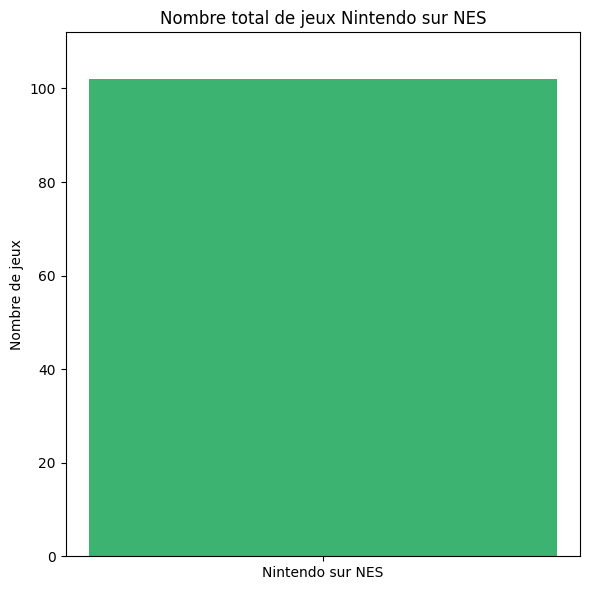

In [9]:
data_nb_jeux = requete_vers_dataframe(conn, """
    SELECT COUNT(DISTINCT J.IDJEU) AS NB_JEUX_NINTENDO_NES
    FROM {1}.COMPAGNIE C
    JOIN {1}.COMPAGNIEJEU CJ ON C.IDCOMPAGNIE = CJ.IDCOMPAGNIE
    JOIN {1}.JEU J ON CJ.IDJEU = J.IDJEU
    JOIN {1}.DATESORTIE DS ON J.IDJEU = DS.IDJEU
    WHERE C.NOMCOMPAGNIE = 'Nintendo'
      AND DS.IDPLATEFORME = 18
""".format(NOM_PLATEFORME, SCHEMA))

nb_jeux = int(data_nb_jeux['NB_JEUX_NINTENDO_NES'].iloc[0])

plt.figure(figsize=(6, 6))
plt.bar(['Nintendo sur NES'], [nb_jeux], color='mediumseagreen')
plt.ylabel("Nombre de jeux")
plt.title("Nombre total de jeux Nintendo sur NES")
plt.ylim(0, nb_jeux + 10)  
plt.tight_layout()
plt.show()


## Comparaison de celle-ci avec les autres plateformes

### 1) Classement des jeux

### Top 10 – notes des joueurs (IGDB)

Ce sont les dix jeux que les joueurs ont le plus aimé sur la NES, avec des notes entre 86 et 98 sur 100.  
- En première place, **Jurassic Park** avec 97,67.  
- Viennent ensuite **Life Force** (96,98) et **Tetris 2** (89,65).  
- Ces chiffres montrent que les joueurs préfèrent surtout les gros titres et les jeux faciles à prendre en main.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

top_user = requete_vers_dataframe(conn, f"""
    SELECT J.TitreJeu, ROUND(AVG(J.ScoreIGDB),2) AS note_utilisateur
    FROM {SCHEMA}.JEU J
    INNER JOIN {SCHEMA}.DATESORTIE DS ON J.IdJeu = DS.IdJeu
    INNER JOIN {SCHEMA}.PLATEFORME P ON DS.IdPlateforme = P.IdPlateforme
    WHERE P.NomPlateforme = '{NOM_PLATEFORME}'
    AND J.ScoreIGDB IS NOT NULL
    GROUP BY J.TitreJeu
    ORDER BY note_utilisateur DESC
    FETCH FIRST 10 ROWS ONLY
""")
print("Top 10 jeux – note utilisateur (IGDB)")
print(top_user)


Top 10 jeux – note utilisateur (IGDB)
              TITREJEU  NOTE_UTILISATEUR
0       BDWarrior 2025            100.00
1        Jurassic Park             97.67
2           Life Force             96.98
3             Tetris 2             89.65
4  Super Mario Bros. 3             89.48
5   Clash at Demonhead             88.75
6             Arkanoid             88.29
7              Pac-Man             87.76
8        Banana Prince             87.06
9          StarTropics             86.89


### Top 10 – note critique

Ce sont les dix jeux que les journalistes et sites spécialisés ont le plus notés.  
- Les critiques choisissent parfois des jeux moins connus pour leur originalité ou leur histoire.  
- Cette liste diffère du classement des joueurs, car les critiques regardent aussi la technique et le scénario.

In [16]:

top_crit = requete_vers_dataframe(conn, f"""
  SELECT J.TitreJeu, ROUND(AVG(J.ScoreAgregeJeu),2) AS note_critique
    FROM {SCHEMA}.JEU J
    INNER JOIN {SCHEMA}.DATESORTIE DS ON J.IdJeu = DS.IdJeu
    INNER JOIN {SCHEMA}.PLATEFORME P ON DS.IdPlateforme = P.IdPlateforme
    WHERE P.NomPlateforme = '{NOM_PLATEFORME}'
    AND J.ScoreAgregeJeu IS NOT NULL
    GROUP BY J.TitreJeu
    ORDER BY note_critique DESC
    FETCH FIRST 10 ROWS ONLY
""")
print("Top 10 jeux – note critique")
print(top_crit)

Top 10 jeux – note critique
                                    TITREJEU  NOTE_CRITIQUE
0                             BDWarrior 2025          100.0
1                         Disney's DuckTales           86.0
2                             Blaster Master           85.0
3                            Blazing Rangers           82.0
4                               Bomberman II           80.0
5                                   Gauntlet           80.0
6            Cybernoid: The Fighting Machine           80.0
7   S.C.A.T.: Special Cybernetic Attack Team           78.0
8                         Adventures of Lolo           77.5
9  A Boy and His Blob: Trouble on Blobolonia           77.0


### Top 10 – notes combinées

Ici, on fait la moyenne des notes des joueurs et des critiques pour ne garder que les jeux appréciés par tout le monde.  
- Les titres de ce top sont à la fois amusants et bien conçus.  
- Ce sont les jeux indispensables pour découvrir le meilleur de la NES.

In [17]:
top_comb = requete_vers_dataframe(conn, f"""
  SELECT J.TitreJeu, ROUND((J.ScoreIGDB+J.ScoreAgregeJeu)/2,2) AS note_combinee
    FROM {SCHEMA}.JEU J
    INNER JOIN {SCHEMA}.DATESORTIE DS ON J.IdJeu = DS.IdJeu
    INNER JOIN {SCHEMA}.PLATEFORME P ON DS.IdPlateforme = P.IdPlateforme
    WHERE P.NomPlateforme = '{NOM_PLATEFORME}'
    AND J.ScoreIGDB IS NOT NULL
    AND J.ScoreAgregeJeu IS NOT NULL
    GROUP BY J.TitreJeu, J.ScoreIGDB, J.ScoreAgregeJeu
    ORDER BY note_combinee DESC
    FETCH FIRST 10 ROWS ONLY
""")
print("Top 10 jeux – note combinée")
print(top_comb)

Top 10 jeux – note combinée
                                   TITREJEU  NOTE_COMBINEE
0                            BDWarrior 2025         100.00
1                        Disney's DuckTales          83.59
2                            Blaster Master          82.15
3                              Bomberman II          80.28
4                        Adventures of Lolo          78.45
5  S.C.A.T.: Special Cybernetic Attack Team          73.93
6                             Final Fantasy          73.46
7                         River City Ransom          73.30
8                         Kirby's Adventure          70.67
9      Crash 'n' the Boys: Street Challenge          70.34


### 2) Répartition des notes par compagnie

Nous examinons ici comment les notes IGDB se répartissent selon les studios qui ont développé ou publié les jeux sur NES.  

- **Moyenne** : note moyenne obtenue par les jeux d’un même studio.  
- **Écart-type** : indique si les notes sont proches de la moyenne (petit écart-type) ou très dispersées (grand écart-type).  
- **Min et Max** : la note la plus faible et la plus élevée attribuées à un jeu du studio.  
- **Médiane** : la note centrale, divisant les jeux en deux groupes de taille égale.  

Par exemple, si Nintendo affiche une moyenne élevée et un écart-type faible, cela signifie que ses jeux sont à la fois bien notés et constants en qualité.

In [18]:
stats_comp = requete_vers_dataframe(conn, f"""
  SELECT C.nomCompagnie,
        ROUND(AVG(J.ScoreIGDB),2) AS moyenne,
        ROUND(STDDEV(J.ScoreIGDB),2) AS ecart_type,
        MIN(J.ScoreIGDB) AS min_note,
        MEDIAN(J.ScoreIGDB) AS mediane,
        MAX(J.ScoreIGDB) AS max_note
    FROM {SCHEMA}.JEU J
    INNER JOIN {SCHEMA}.COMPAGNIEJEU CJ ON CJ.IdJeu = J.IdJeu
    INNER JOIN {SCHEMA}.COMPAGNIE C ON C.IdCompagnie = CJ.IdCompagnie
    INNER JOIN {SCHEMA}.DATESORTIE DS ON DS.IdJeu = J.IdJeu
    INNER JOIN {SCHEMA}.PLATEFORME P ON DS.IdPlateforme = P.IdPlateforme
    WHERE P.NomPlateforme = '{NOM_PLATEFORME}'
    AND J.ScoreIGDB IS NOT NULL
    GROUP BY C.nomCompagnie
    ORDER BY moyenne DESC
""")
print("Répartition ScoreIGDB par compagnie")
print(stats_comp.head(10))

Répartition ScoreIGDB par compagnie
              NOMCOMPAGNIE  MOYENNE  ECART_TYPE    MIN_NOTE     MEDIANE  \
0  Interplay Entertainment   100.00        0.00  100.000000  100.000000   
1    Bullet-Proof Software    89.65        0.00   89.648915   89.648915   
2            Namco Hometek    87.76        0.00   87.763768   87.763768   
3   Locomotive Corporation    84.09        3.83   79.894608   86.885415   
4         Koei Tecmo Games    82.48        0.00   82.476047   82.476047   
5   Sega Enterprises, Ltd.    82.01        0.00   82.013382   82.013382   
6        ASCII Corporation    82.01        0.00   82.013382   82.013382   
7    KGD Software Products    82.01        0.00   82.013382   82.013382   
8            Kogado Studio    82.01        0.00   82.013382   82.013382   
9            Make Software    81.28        2.96   78.495867   81.363346   

     MAX_NOTE  
0  100.000000  
1   89.648915  
2   87.763768  
3   86.885415  
4   82.476047  
5   82.013382  
6   82.013382  
7   82.013

### Bonus : Répartition des jeux par genre
Sur la NES, les jeux de **plateforme** et d’**arcade** représentent la majorité des titres, mais ne se distinguent pas par des notes très élevées (autour de 67/100). En revanche, les genres **RPG** et **puzzle**, bien que beaucoup moins nombreux, obtiennent les meilleures notes (plus de 71/100), montrant que les joueurs apprécient particulièrement ces expériences de niche.  

Les jeux de type **shooter** et **racing** sont aussi nombreux que les RPG, mais leurs notes moyennes (63/100 et 64/100) sont plus modestes. Enfin, les genres très spécialisés comme les **simulateurs** ou les **jeux de cartes/plateaux** sont peu présents et affichent les notes les plus basses, sans doute en raison de leurs mécaniques moins adaptées aux contraintes techniques de la console.  

In [19]:
stats_genre = requete_vers_dataframe(conn, f"""
  SELECT G.NomGenre,
        COUNT(*) AS nb_jeux,
        ROUND(AVG(J.ScoreIGDB),2) AS note_moyenne
    FROM {SCHEMA}.JEU J
    INNER JOIN {SCHEMA}.GENREJEU GJ ON GJ.IdJeu = J.IdJeu
    INNER JOIN {SCHEMA}.GENRE G ON G.IdGenre = GJ.IdGenre
    INNER JOIN {SCHEMA}.DATESORTIE DS ON DS.IdJeu = J.IdJeu
    INNER JOIN {SCHEMA}.PLATEFORME P  ON DS.IdPlateforme = P.IdPlateforme
    WHERE P.NomPlateforme = '{NOM_PLATEFORME}'
    AND J.ScoreIGDB IS NOT NULL
    GROUP BY G.NomGenre
    ORDER BY nb_jeux DESC
""")
print("Répartition par genre (nb + note moyenne)")
print(stats_genre)


Répartition par genre (nb + note moyenne)
                      NOMGENRE  NB_JEUX  NOTE_MOYENNE
0                     Platform      291         67.25
1                    Adventure      210         70.36
2                       Arcade      153         67.26
3                      Shooter      135         63.32
4                        Sport       61         66.23
5   Hack and slash/Beat 'em up       59         68.26
6                       Puzzle       56         71.29
7                     Fighting       42         66.75
8                       Racing       39         64.17
9           Role-playing (RPG)       38         72.16
10                    Strategy       26         68.58
11                   Simulator       19         51.84
12                 Quiz/Trivia        7         52.61
13           Card & Board Game        5         43.80
14                     Pinball        3         61.51
15   Turn-based strategy (TBS)        1         70.67


### 3) Évolution à long terme du Top 3 des compagnies

- **Namco Hometek** conserve une note très élevée (87–88) sur toute la période 1984–2013, ce qui montre une grande constance dans la qualité de ses jeux.  
- **Locomotive Corporation** démarre fort en 1990 (87) puis connaît quelques fluctuations avant de remonter en 2008 (85). Cela reflète un studio capable de revenir en grâce après des années plus calmes.  
- **Koei Tecmo Games** commence autour de 82 en 1991, baisse légèrement en milieu de période (70–75), puis remonte autour de 82–83 en 2005–2008. Cela correspond aux succès de certaines de leurs franchises de stratégie et RPG.  

Globalement, ces trois compagnies montrent qu’un bon démarrage ne suffit pas : il faut savoir innover et maintenir la qualité pour rester au top sur plusieurs générations de consoles.  

In [20]:
top3_sql = f"""
WITH top3 AS (
    SELECT C.IdCompagnie
    FROM {SCHEMA}.JEU J
    INNER JOIN {SCHEMA}.COMPAGNIEJEU CJ ON CJ.IdJeu = J.IdJeu AND CJ.EstDeveloppeur = 1
    INNER JOIN {SCHEMA}.COMPAGNIE C ON C.IdCompagnie = CJ.IdCompagnie
    INNER JOIN {SCHEMA}.DATESORTIE DS ON DS.IdJeu = J.IdJeu
    WHERE DS.IdPlateforme = :plat
    AND J.ScoreIGDB IS NOT NULL
    GROUP BY C.IdCompagnie
    ORDER BY AVG(J.ScoreIGDB) DESC
    FETCH FIRST 3 ROWS ONLY
)
SELECT C.IdCompagnie, C.nomCompagnie, ROUND(AVG(J.ScoreIGDB),2) AS moy
    FROM {SCHEMA}.JEU J
    INNER JOIN {SCHEMA}.COMPAGNIEJEU CJ ON CJ.IdJeu = J.IdJeu AND CJ.EstDeveloppeur = 1
    INNER JOIN {SCHEMA}.COMPAGNIE C ON C.IdCompagnie = CJ.IdCompagnie
    INNER JOIN {SCHEMA}.DATESORTIE DS ON DS.IdJeu = J.IdJeu
    WHERE DS.IdPlateforme = :plat
    AND J.ScoreIGDB IS NOT NULL
    AND C.IdCompagnie IN (SELECT IdCompagnie FROM top3)
    GROUP BY C.IdCompagnie, C.nomCompagnie
    ORDER BY moy DESC
"""
top3_nin = requete_vers_dataframe(conn, top3_sql, {"plat": id_plateforme})
print("► Top 3 compagnies Nintendo (ScoreIGDB)")
print(top3_nin)

evo_sql = f"""
WITH top3 AS (
    SELECT C.IdCompagnie
    FROM {SCHEMA}.JEU J
    INNER JOIN {SCHEMA}.COMPAGNIEJEU CJ ON CJ.IdJeu = J.IdJeu AND CJ.EstDeveloppeur = 1
    INNER JOIN {SCHEMA}.COMPAGNIE C ON C.IdCompagnie = CJ.IdCompagnie
    INNER JOIN {SCHEMA}.DATESORTIE DS ON DS.IdJeu = J.IdJeu
    WHERE DS.IdPlateforme = :plat
    AND J.ScoreIGDB IS NOT NULL
    GROUP BY C.IdCompagnie
    ORDER BY AVG(J.ScoreIGDB) DESC
    FETCH FIRST 3 ROWS ONLY
)
SELECT C.nomCompagnie,
       TO_CHAR(DS.DateSortie,'YYYY') AS annee,
       ROUND(AVG(J.ScoreIGDB),2) AS note
    FROM {SCHEMA}.JEU J
    INNER JOIN {SCHEMA}.COMPAGNIEJEU CJ ON CJ.IdJeu = J.IdJeu
    INNER JOIN {SCHEMA}.COMPAGNIE C ON C.IdCompagnie = CJ.IdCompagnie
    INNER JOIN {SCHEMA}.DATESORTIE DS ON DS.IdJeu = J.IdJeu
    WHERE J.ScoreIGDB IS NOT NULL
    AND C.IdCompagnie IN (SELECT IdCompagnie FROM top3)
    GROUP BY C.nomCompagnie, TO_CHAR(DS.DateSortie,'YYYY')
    ORDER BY C.nomCompagnie, annee
"""
top3_evo = requete_vers_dataframe(conn, evo_sql, {"plat": id_plateforme})
print("► Évolution annuelle du Top 3")
print(top3_evo)

► Top 3 compagnies Nintendo (ScoreIGDB)
   IDCOMPAGNIE             NOMCOMPAGNIE     MOY
0            5  Interplay Entertainment  100.00
1        10070            Namco Hometek   87.76
2        45549   Locomotive Corporation   84.09
► Évolution annuelle du Top 3
               NOMCOMPAGNIE ANNEE    NOTE
0   Interplay Entertainment  0028  100.00
1   Interplay Entertainment  1992   58.00
2   Interplay Entertainment  1993   76.48
3   Interplay Entertainment  1995   75.25
4   Interplay Entertainment  1996   76.60
5   Interplay Entertainment  1997   79.41
6   Interplay Entertainment  2002   65.07
7    Locomotive Corporation  1990   86.89
8    Locomotive Corporation  1992   86.89
9    Locomotive Corporation  1994   80.83
10   Locomotive Corporation  1995   76.63
11   Locomotive Corporation  1997   68.39
12   Locomotive Corporation  1998   68.26
13   Locomotive Corporation  1999   59.49
14   Locomotive Corporation  2008   85.14
15   Locomotive Corporation  2009   77.72
16   Locomotive Corporat

### Même démarche sur le nombre de jeux

On calcule pour chaque plateforme et chaque année le nombre de jeux distincts sortis, puis on regarde un extrait des résultats ci-dessous.

- **Cycle de vie des consoles**  
  - Au lancement, le nombre de titres est très faible (ex. : 1 jeu en 1977 pour la 1292 APVS).  
  - Dans la phase de croissance, on observe un pic de production (ex. : 11 jeux en 1979 pour la 1292 APVS, 102 jeux en 1995 pour la 3DO).  
  - En fin de vie, la production chute rapidement avant de s’arrêter.

- **Cas particuliers**  
  - De vieilles consoles peuvent parfois recevoir un jeu isolé des années plus tard (ex. : 1 jeu en 2023 sur la 1292 APVS), signe d’initiatives homebrew ou de rééditions.

Ce tableau met en évidence la montée en puissance, la maturité et le déclin de chaque plateforme en fonction du nombre de jeux publiés chaque année.  

In [21]:
data_nb_par_annee = requete_vers_dataframe(conn, f"""
  SELECT P.nomPlateforme,
         TO_CHAR(DS.DateSortie,'YYYY') AS annee,
         COUNT(DISTINCT DS.IdJeu) AS nb_jeux
    FROM {SCHEMA}.DATESORTIE DS
    INNER JOIN {SCHEMA}.PLATEFORME P ON P.IdPlateforme = DS.IdPlateforme
    GROUP BY P.nomPlateforme, TO_CHAR(DS.DateSortie,'YYYY')
    ORDER BY P.nomPlateforme, annee
""")
print("Jeux publiés par année et plateforme")
print(data_nb_par_annee.head(10))

Jeux publiés par année et plateforme
                             NOMPLATEFORME ANNEE  NB_JEUX
0  1292 Advanced Programmable Video System  1977        1
1  1292 Advanced Programmable Video System  1979       11
2  1292 Advanced Programmable Video System  1980        4
3  1292 Advanced Programmable Video System  1981        3
4  1292 Advanced Programmable Video System  1982        1
5  1292 Advanced Programmable Video System  2023        1
6              3DO Interactive Multiplayer  1993       10
7              3DO Interactive Multiplayer  1994       94
8              3DO Interactive Multiplayer  1995      102
9              3DO Interactive Multiplayer  1996       22


### 5) Évolution du nombre total de jeux sur toutes les plateformes

On calcule pour chaque année le nombre total de jeux distincts toutes consoles confondues, puis on trace un histogramme pour visualiser la tendance.

- **1947–1970 : des débuts très limités**  
  Durant cette période pionnière, on recense à peine un jeu par an. L’industrie est embryonnaire, avec des prototypes et des bornes d’arcade expérimentales. Les technologies et les canaux de distribution n’existent pas encore sous une forme commerciale mature.

- **1980s : la première explosion**  
  L’arrivée de consoles comme l’Atari 2600 puis la NES fait basculer le marché de quelques titres à plusieurs centaines chaque année. Les éditeurs commencent à investir massivement, et les gamers découvrent une offre de plus en plus diversifiée. Cette décennie pose les bases d’un secteur vidéoludique structuré.

- **Fin 80s–début 90s : phase de stabilisation**  
  Après l’engouement initial, la production se maintient autour de 1 200–1 500 jeux par an. Les grandes enseignes (Nintendo, Sega) consolident leur catalogue tandis que naissent des studios spécialisés. Le rythme de sorties se régularise, posant les fondations d’un marché mature.

- **Années 2000 : renouveau et transition**  
  L’essor des consoles de sixième génération (PS2, Xbox, GameCube) propulse de nouveau le nombre de sorties au-delà de 2 000 titres par an. On observe aussi l’émergence de jeux PC distribués en ligne et de nouveaux genres (MMO, jeux mobiles naissants). Le virage digital commence à remodeler la chaîne de production et de diffusion.

- **2010s–2020s : explosion de l’indépendant et du dématérialisé**  
  Après un léger repli autour de 2012–2014, la démocratisation des outils de développement et des plateformes en ligne entraîne une croissance rapide : 4 000–5 000 jeux publiés annuellement. Les studios indépendants et les services de téléchargement (Steam, eShop, PlayStation Store) amplifient cette tendance, offrant une offre pléthorique aux joueurs.  

Total de jeux par année
   ANNEE  TOTAL_JEUX
0   0028           1
1   1947           1
2   1948           1
3   1950           1
4   1952           1
..   ...         ...
63  2021        2663
64  2022        3182
65  2023        4064
66  2024        5090
67  2025        1244

[68 rows x 2 columns]


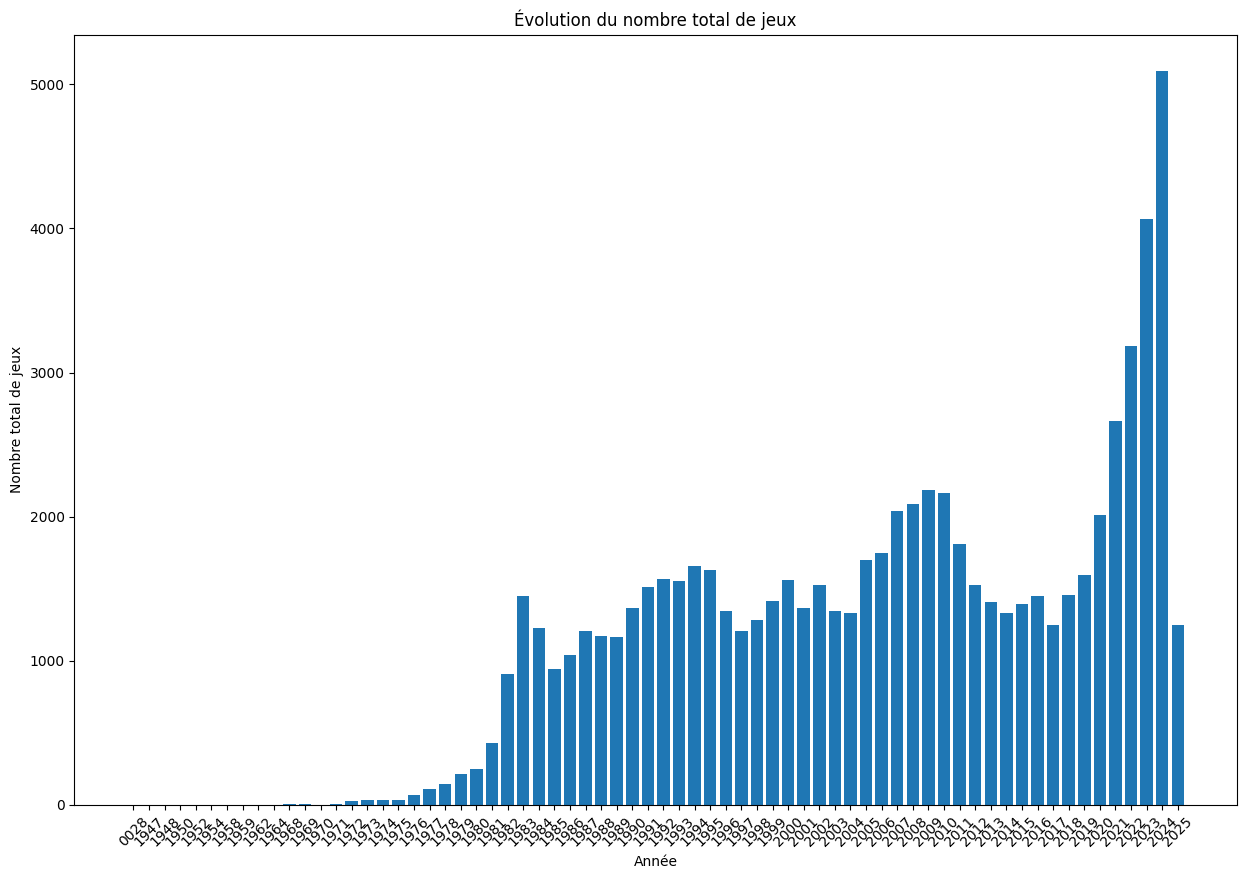

In [22]:
data_total_annee = requete_vers_dataframe(conn, f"""
    SELECT TO_CHAR(DS.DateSortie,'YYYY') AS annee,
            COUNT(DISTINCT DS.IdJeu) AS total_jeux
    FROM {SCHEMA}.DATESORTIE DS
    WHERE DS.DateSortie IS NOT NULL
    AND DS.DateSortie <= SYSDATE
    GROUP BY TO_CHAR(DS.DateSortie,'YYYY')
    ORDER BY annee
""")
print("Total de jeux par année")
print(data_total_annee)

# Histogramme
df_hist = data_total_annee.dropna(subset=['ANNEE','TOTAL_JEUX']).copy()
df_hist['ANNEE'] = df_hist['ANNEE'].astype(str)
df_hist['TOTAL_JEUX'] = df_hist['TOTAL_JEUX'].astype(int)

plt.figure(figsize=(15,10))
plt.bar(df_hist['ANNEE'], df_hist['TOTAL_JEUX'])
plt.xticks(rotation=45)
plt.xlabel("Année")
plt.ylabel("Nombre total de jeux")
plt.title("Évolution du nombre total de jeux")
plt.show()


# Comparaison de Nintendo avec les autres compagnies plateformes
 
- **Nintendo**, en tant qu’éditeur majeur, affiche une moyenne respectable (69 %) mais avec une forte dispersion : certains titres (Tetris, Mario…) sont plébiscités (> 80 %), tandis que d’autres obtiennent des notes plus modestes (< 40 %).  
- À l’inverse, des studios de niche comme **Bullet-Proof Software** ou **Namco Hometek** ne sortent qu’un ou deux jeux très bien notés : leur écart-type est nul (pas de variation) et leurs moyennes dépassent 87 %.  
- **Locomotive Corporation** montre une variabilité notable (écart-type ~ 3,8 %), signe d’un catalogue plus divers, avec quelques hits forts et quelques titres moins réussis.  
- Cette comparaison illustre qu’un éditeur généraliste comme Nintendo produit une grande diversité de jeux (et donc des performances variées), tandis que des studios plus petits misent sur quelques titres de haute qualité, garantissant des moyennes plus élevées et stables.  

In [23]:
stats_selection = requete_vers_dataframe(conn, f"""
SELECT 
    C.nomCompagnie,
    ROUND(AVG(J.ScoreIGDB), 2) AS moyenne,
    ROUND(STDDEV(J.ScoreIGDB), 2) AS ecart_type,
    MIN(J.ScoreIGDB) AS min_note,
    MEDIAN(J.ScoreIGDB) AS mediane,
    MAX(J.ScoreIGDB) AS max_note
    FROM {SCHEMA}.JEU J
        INNER JOIN {SCHEMA}.COMPAGNIEJEU CJ ON CJ.IdJeu = J.IdJeu
        INNER JOIN {SCHEMA}.COMPAGNIE C ON C.IdCompagnie = CJ.IdCompagnie
        INNER JOIN {SCHEMA}.DATESORTIE DS ON DS.IdJeu = J.IdJeu
        INNER JOIN {SCHEMA}.PLATEFORME P ON DS.IdPlateforme = P.IdPlateforme
    WHERE P.NomPlateforme = 'Nintendo Entertainment System'
    AND J.ScoreIGDB IS NOT NULL
    GROUP BY C.nomCompagnie
    ORDER BY CASE WHEN C.nomCompagnie = 'Nintendo' THEN 0 ELSE 1 END, moyenne DESC
""")

print(stats_selection)

                NOMCOMPAGNIE  MOYENNE  ECART_TYPE    MIN_NOTE     MEDIANE  \
0                   Nintendo    69.06       11.73   30.153936   69.928783   
1    Interplay Entertainment   100.00        0.00  100.000000  100.000000   
2      Bullet-Proof Software    89.65        0.00   89.648915   89.648915   
3              Namco Hometek    87.76        0.00   87.763768   87.763768   
4     Locomotive Corporation    84.09        3.83   79.894608   86.885415   
..                       ...      ...         ...         ...         ...   
242            GameTek, Inc.    32.43        0.00   32.427584   32.427584   
243    Magnin and Associates    31.88        0.00   31.884262   31.884262   
244      Hi-Tech Expressions    13.18        0.00   13.178726   13.178726   
245            Krome Studios    13.15        0.00   13.153018   13.153018   
246       Active Enterprises    12.28        0.00   12.276910   12.276910   

       MAX_NOTE  
0     89.648915  
1    100.000000  
2     89.648915  
3  

# Contributions de la compagnie choisie sur la plateforme qui vous a été assignée

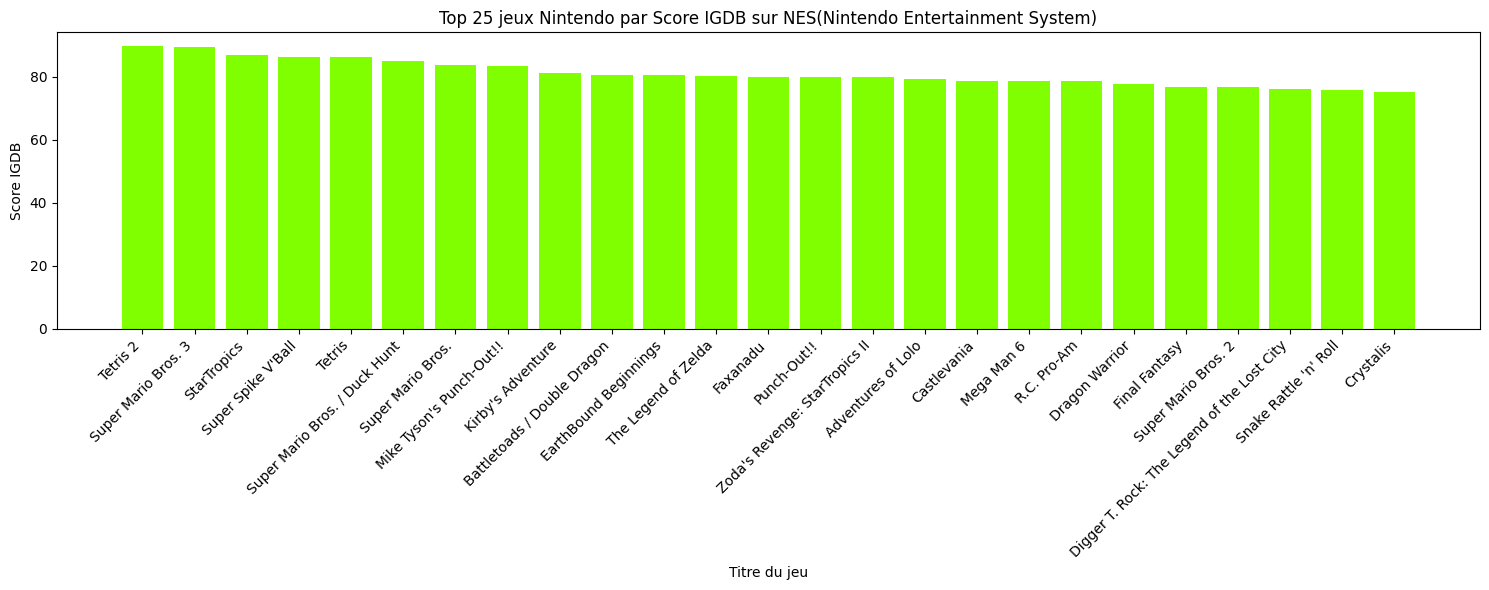

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# Récupération des données
data_comp = requete_vers_dataframe(conn, """
    SELECT DISTINCT TitreJeu, ScoreIGDB
    FROM {1}.Compagnie C
    INNER JOIN {1}.COMPAGNIEJEU CJ ON C.IDCOMPAGNIE = CJ.IDCOMPAGNIE
    INNER JOIN {1}.JEU J ON J.IdJeu = CJ.IdJeu
    INNER JOIN {1}.DATESORTIE DS ON J.IdJeu = DS.IdJeu
    INNER JOIN {1}.PLATEFORME P ON P.IdPlateforme = DS.IdPlateforme
    WHERE P.IdPlateforme = 18 AND SCOREIGDB IS NOT NULL
    AND NomCompagnie = 'Nintendo' 
    ORDER BY ScoreIGDB DESC
""".format(NOM_PLATEFORME, SCHEMA))

xpoint = np.array(data_comp['TITREJEU'][0:25].to_list())
ypoint = np.array(data_comp['SCOREIGDB'][0:25].to_list())

plt.figure(figsize=(15, 6))
plt.bar(xpoint, ypoint, color='chartreuse')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Titre du jeu")
plt.ylabel("Score IGDB")
plt.title("Top 25 jeux Nintendo par Score IGDB sur NES({})".format(NOM_PLATEFORME))
plt.tight_layout()
plt.show()


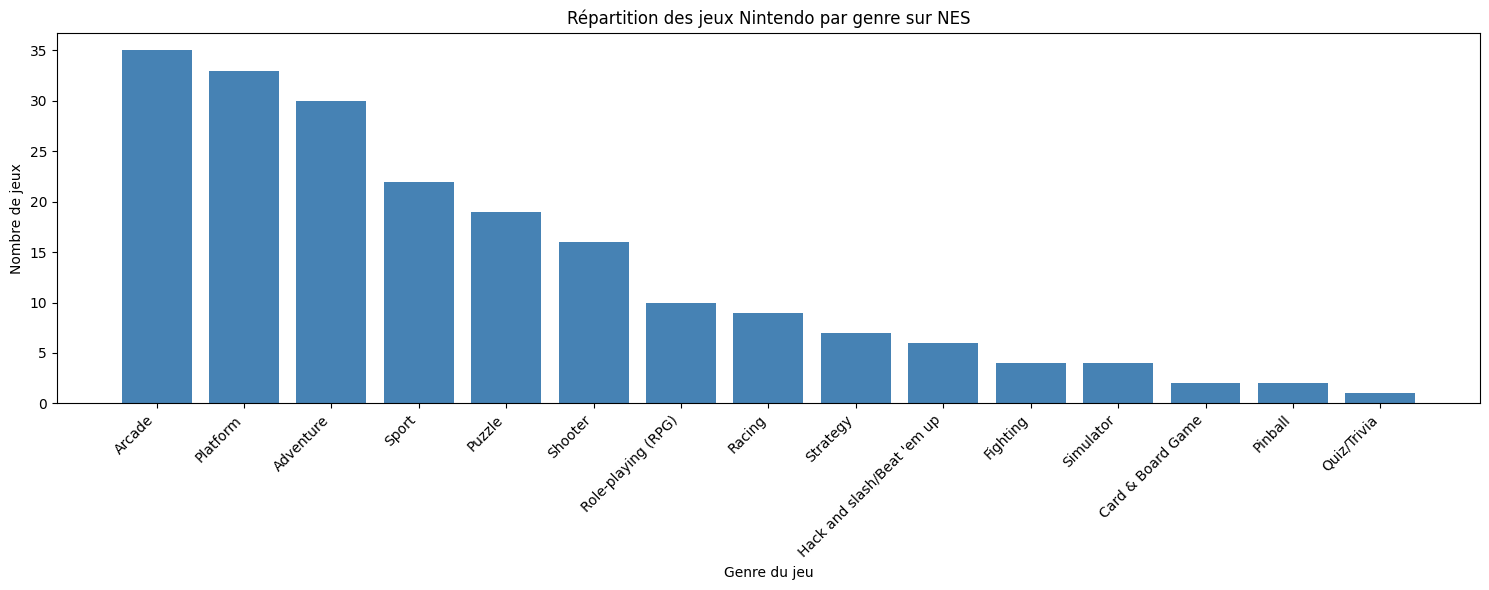

In [36]:
# Récupération des données
data_comp = requete_vers_dataframe(conn, """
SELECT 
    g.NOMGENRE,
    COUNT(DISTINCT j.IDJEU) AS nb_jeux
FROM {1}.JEU j
JOIN {1}.DATESORTIE ds ON j.IDJEU = ds.IDJEU
JOIN {1}.COMPAGNIEJEU cj ON j.IDJEU = cj.IDJEU
JOIN {1}.COMPAGNIE c ON cj.IDCOMPAGNIE = c.IDCOMPAGNIE
JOIN {1}.GENREJEU gj ON j.IDJEU = gj.IDJEU
JOIN {1}.GENRE g ON gj.IDGENRE = g.IDGENRE
WHERE ds.IDPLATEFORME = 18
  AND cj.ESTPUBLIEUR = 1
  AND c.NOMCOMPAGNIE = 'Nintendo'
GROUP BY g.NOMGENRE
ORDER BY nb_jeux DESC
""".format(NOM_PLATEFORME, SCHEMA))


xpoint = np.array(data_comp['NOMGENRE'][0:25].to_list())
ypoint = np.array(data_comp['NB_JEUX'][0:25].to_list())

# Affichage du graphique
plt.figure(figsize=(15, 6))
plt.bar(xpoint, ypoint, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Genre du jeu")
plt.ylabel("Nombre de jeux")
plt.title("Répartition des jeux Nintendo par genre sur NES")
plt.tight_layout()
plt.show()


# Evolution de la compagnie

Nintendo, ça a changé comment ?
Nintendo, au départ, ce n’était même pas du jeu vidéo. Ils faisaient des cartes à jouer au 19e siècle ! Puis, dans les années 80, ils sortent Donkey Kong, et là, c’est le début de quelque chose de grand.
Les grandes années
Avec la NES puis la Super Nintendo, Nintendo devient un nom que tout le monde connaît. On découvre Mario, Zelda, Pokémon… des jeux qui marquent des générations.
Ensuite, il y a eu la Nintendo 64 et la GameCube. Des consoles cool, mais un peu moins populaires à cause de la concurrence.
Le gros carton : la Wii
En 2006, ils sortent la Wii. Tout le monde y joue, même les parents et les grands-parents ! C’est un carton mondial.
 La DS, leur console portable, explose aussi tous les records.
Le flop : la Wii U
Après ce succès, la Wii U déçoit. Pas assez claire, pas assez de jeux... les gens ne comprennent pas trop le concept. C’est un vrai raté.
Le retour du roi : la Switch
En 2017, Nintendo revient fort avec la Switch. Une console qu’on peut brancher à la télé et emmener partout. Les gens adorent. Les ventes explosent. On joue à Mario, Zelda, Animal Crossing, partout, tout le temps.

Et sur les autres écrans ?
Nintendo ne met (presque) jamais ses jeux ailleurs. Pas de Mario sur PlayStation ou Xbox.
 Mais ils ont quand même tenté quelques jeux sur mobile, et surtout :
Un film Mario (énorme succès)


Des parcs à thème (avec Universal)


Et plein de produits dérivés


Ils deviennent plus qu’un créateur de jeux : une vraie marque de divertissement.

Et demain ?
Ce qui va bien :
Ils ont des licences cultes que tout le monde aime.


Ils font les choses à leur manière, et ça marche.


Ils savent surprendre.


Ce qu’ils doivent faire attention :
Ne pas trop vivre sur leurs classiques.


Réussir la console qui vient après la Switch.


Suivre un peu les nouvelles tendances (cloud, jeux en ligne, etc.)


En résumé :
Nintendo a connu des hauts et des bas, mais ils savent toujours rebondir. Avec tout ce qu’ils préparent (cinéma, nouvelle console...), on peut s’attendre à les voir encore longtemps au top.


Source: 
cincodias.elpais.com (https://cincodias.elpais.com/mercados-financieros/2025-06-19/nintendo-se-dispara-en-bolsa-tras-un-record-de-ventas-de-la-switch-2-que-escasea-en-espana.html)
indiatimes.com (https://www.indiatimes.com/trending/nintendo-switch-2-breaks-records-35-million-units-sold-worldwide-in-4-days-sets-new-global-launch-benchmark-660809.html)
laptopmag.com (https://www.laptopmag.com/gaming/nintendo/switch-2-pulled-off-something-no-console-maker-has-before)
https://fr.wikipedia.org (https://en.wikipedia.org/wiki/History_of_Nintendo)

In [47]:
! jupyter nbconvert --to pdf Partie2.ipynb

/opt/conda/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=45) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


[NbConvertApp] Converting notebook Partie2.ipynb to pdf
[NbConvertApp] Support files will be in Partie2_files/
[NbConvertApp] Making directory ./Partie2_files
[NbConvertApp] Writing 85714 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 398070 bytes to Partie2.pdf
